In [2]:
#LIBRARIES
import numpy as np
from scipy.optimize import fsolve
from scipy.special import erf
from scipy.special import erfc
from scipy.special import ndtr as gaussian_cdf
from scipy.special import gamma, gammaln
from scipy.stats import norm
from scipy import integrate
from scipy.special import factorial
import matplotlib.pyplot as plt
import re
import pandas as pd
from scipy.integrate import quad
import matplotlib.gridspec as gridspec
import os

#THEORY


#CALCULATE XC EXACTLY GIVEN SIMULATION V
def calculate_xc_twoparam(v,sb,Ub):
    # Initial guesses for xc:
    # First one from MM regime
    guess_xc_mm = v/sb*np.log(sb/Ub)+sb/2
    # Second one from QS regime
    guess_xc_qs = np.sqrt(2*v*np.log(v/Ub/sb))
    #print(guess_xc_mm,guess_xc_qs)
    # Take larger of the two
    guess_xc = max([guess_xc_mm,guess_xc_qs])
    # Solve for xc numerically using starting guess
    condition = lambda x: constrain_xc_exact(x,v,sb,Ub)
    xc=fsolve(condition,guess_xc)[0]
    return xc
def constrain_xc_exact(xc,v,s,Ub):
    return calculate_logNpfix_beneficial(s,xc,v,s,Ub)+np.log(s*Ub/v)
def calculate_logNpfix_beneficial(s,xc,v,sb,Ub):
    value_without_xcsv = (v/s/sb)*(np.exp(-s*s/2/v)*(-1*np.expm1(-xc*s/v)) + np.exp(xc**2/(2*v)-xc*s/v)*(np.sqrt(np.pi/(2*v)))*(s**2/xc)*2*gaussian_cdf((s-xc)/np.sqrt(v)))
    if value_without_xcsv<0:
        print("Bad value:", s,xc,v,sb,Ub,value_without_xcsv)
    #return np.log(value)
    return xc*s/v+np.log(value_without_xcsv)


#relative substitution rate of single transfers
def substitution_rate_singlets(v,sb,Ub,r,l,L):
    xc = calculate_xc_twoparam(v,sb,Ub)
    q=xc/sb
    ratio=r*l*q/(Ub*2)
    return ratio


#relative substitution rate of colocalized pairs
def substitution_rate_coloc_pairs(v,sb,Ub,r,l,L):
    xc = calculate_xc_twoparam(v,sb,Ub)
    q=xc/sb
    xcr2= calculate_xc_twoparam(v,2*sb,r*l/2)
    ratio=np.exp(((xc-sb)**2-(xcr2-sb)**2)/(2*v))*(xcr2**2)/(xc*sb)*(l*q/L)
    return ratio

#relative substitution rate of colocalized triplets
def substitution_rate_coloc_triplets(v,sb,Ub,r,l,L):
    xc = calculate_xc_twoparam(v,sb,Ub)
    q=xc/sb
    if xc-3*sb > np.sqrt(v):
        xcr3= calculate_xc_twoparam(v,3*sb,r*l/2)
        ratio=np.exp(((xc-sb)**2-(xcr3-sb)**2)/(2*v))*(xcr3**2)/(sb*xc)*(l*q/L)**2
        return ratio
    else: 
        ratio = 0
        return ratio

#1-FRACTION MUTATIONS FIXING ON ORIGINAL BACKGROUND
def calculate_substitution_rate(v,sb,Ub,r,l,L):
    ratio_1 = substitution_rate_singlets(v,sb,Ub,r,l,L)
    ratio_2 = substitution_rate_coloc_pairs(v,sb,Ub,r,l,L)
    ratio_3 = substitution_rate_coloc_triplets(v,sb,Ub,r,l,L)
    norm=ratio_1+ratio_2+ratio_3
    return norm/(1+norm)

#Solve for rate of adaptation
def v_condition(v,N,sb,Ub,r,l,L):
    xc = calculate_xc_twoparam(v,sb,Ub)
    if r>0:
        ratio_1 = substitution_rate_singlets(v,sb,Ub,r,l,L)
        ratio_2 = substitution_rate_coloc_pairs(v,sb,Ub,r,l,L)
        ratio_3 = substitution_rate_coloc_triplets(v,sb,Ub,r,l,L)
        return np.log(N*Ub*xc/np.sqrt(2*np.pi*v)) - (xc-sb)**2/(2*v) + np.log(1+ratio_1+ratio_2+ratio_3)
    else:
        return np.log(N*Ub*xc/np.sqrt(2*np.pi*v))- (xc-sb)**2/(2*v)

def theory_v(N, sb, Ub, r, l, L):
    # Desai-Fisher initial guess for v
    guess = 2 * sb**2 * np.log(N*np.sqrt(sb*Ub)) / (np.log(sb/Ub)**2)

    def F(v):
        return v_condition(v,N, sb, Ub, r, l, L)

    v_solution = fsolve(F, guess)[0]
    return v_solution


def theory_v_ratio(N, sb, Ub, r, l, L):
    sexual_v=theory_v(N, sb, Ub, r, l, L)
    asexual_v=theory_v(N, sb, Ub, 0, l, L)
    return sexual_v/asexual_v-1

def theory_ratio_r_dom(N,v,sb,Ub,r,l,L):
    rl=r*l
    xc = calculate_xc_twoparam(v,sb,Ub)
    q=xc/sb
    q0=(4*np.log(N*sb))/np.log(sb/rl)
    A=q0/2*np.log(rl*sb/Ub**2)+1/2*np.log(Ub/sb)
    B=(1+1/q)*np.log(L/(q*l))
    if A-B<0:
        return -1
    gamma1=max(0,q/2*np.log((A/(A-B))))
    gamma2=max(0,A-gamma1)
    return gamma2/(gamma1+gamma2)
    
def theory_v_ratio_r_dom(N,v, sb, Ub, r, l, L):
    rl=r*l
    xc = calculate_xc_twoparam(v,sb,Ub)
    q=xc/sb
    q0=4*np.log(N*sb)/np.log(sb/rl)
    A=q0/2*np.log(rl*sb/Ub**2)+1/2*np.log(Ub/sb)
    B=(1+1/q)*np.log(L/(q*l))
    if A-B<0:
        return -1
    gamma1=max(0,q/2*np.log((A/(A-B))))
    gamma2=max(0,A-gamma1)
    r1=gamma2/gamma1
    r2=np.log(sb/Ub)/np.log(sb/rl) #q0/qa
    term=(2*gamma1+gamma2)/(4*np.log(N*sb))
    num=1+r1*r2*(1-term)
    denom=1+1/2*r1/r2*(1+term)
    return num/denom-1


def dominant_tuplet(v,sb,Ub,r,l,L):
    ratio_1 = substitution_rate_singlets(v,sb,Ub,r,l,L)
    ratio_2 = substitution_rate_coloc_pairs(v,sb,Ub,r,l,L)
    ratio_3 = substitution_rate_coloc_triplets(v,sb,Ub,r,l,L)
    norm=ratio_1+ratio_2+ratio_3
    ratios=[ratio_1/norm, ratio_2/norm, ratio_3/norm]
    return ratios


In [266]:
folder_path='/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_7_2'

# Initialize an empty list to store data
master_data = []

# Iterate over all files in the folder
for file_name in os.listdir(folder_path):
    if file_name.startswith('simulation_'):
        file_path = os.path.join(folder_path, file_name)
        
        # Read the CSV file

        df = pd.read_csv(file_path, sep='\t', header=None, skiprows=25)
        
        # Extract columns 1 through 4 (index 0 to 3)
        selected_data = df.iloc[:, 1:5]
        
        # Append to the master data list
        master_data.append(selected_data)

# Combine all data into a single DataFrame
master_df = pd.concat(master_data, ignore_index=True)
#columns=['Distance','fA','fB','fAB']
# Rename the columnsv
master_df.columns = ['Distance', 'fA', 'fB', 'fAB']
#save as csv
master_df.to_csv('/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_7_2/all_data.csv', index=False)

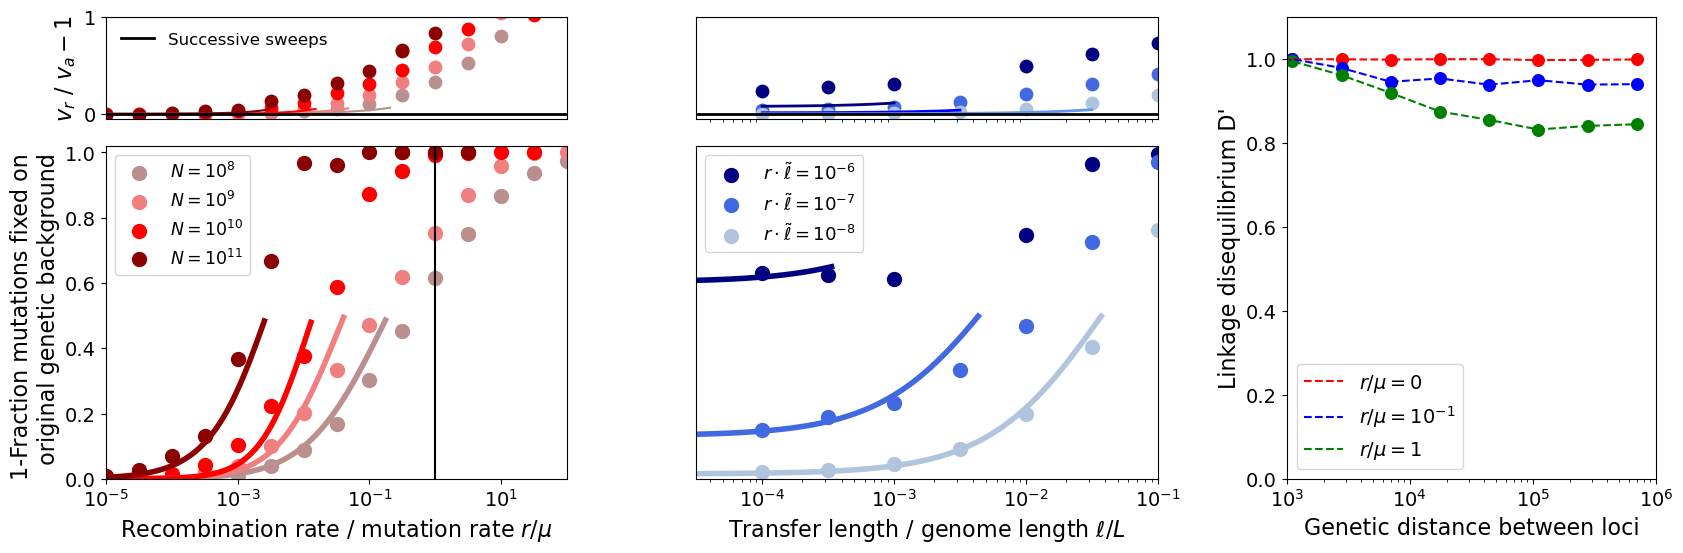

Dominant tuplet N=1e8: [0.24680025415251097, 0.7531997458474892, 0.0] Crossover: 0.5010810172378932
Dominant tuplet N=1e9: [0.06326512280734661, 0.9367348771926534, 0.0] Crossover: 0.5080709590235911
Dominant tuplet N=1e10: [0.02390262776386234, 0.9760973722361377, 0.0] Crossover: 0.5194957705328864
Dominant tuplet N=1e11: [0.0052696148800152045, 0.3483321452739226, 0.6463982398460622] Crossover: 0.49914695134611836


In [4]:
####################################################################################################################################################
#SIMULATED FILES AND PARAMETERS

#SIMULATION PARAMETERS
Ub=.000001 #beneficial mutation rate
sb=.05 #beneficial selection coefficient
L=1e6 #genome length
l=1e4 #transfer length
rls=[10**-11,10**-10,10**-9,10**-8,10**-7,10**-6,10**-5,10**-4] #transfer rates

#SIMULATED ASEXUAL RATES OF ADAPTATION
v_N8=0.000496578
v_N9=0.000594526
v_N10=0.000687463
v_N11=0.000789328

#CALCULATE WIDTH OF FITNESS DISTRIBUTION FROM SIMULATED V
q_N8=calculate_xc_twoparam(v_N8,sb,Ub)/sb
q_N9=calculate_xc_twoparam(v_N9,sb,Ub)/sb
q_N10=calculate_xc_twoparam(v_N10,sb,Ub)/sb
q_N11=calculate_xc_twoparam(v_N11,sb,Ub)/sb


#DATA FILES
file1='/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2c/simulation_results.csv'
file2='/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2b/simulation_results.csv'


# Redefine simulation paths
file1 = '/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/HGT Codes_9_24_2024/Figure_Data/Figure 2d/simulation_results.csv'
file2 = '/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/HGT Codes_9_24_2024/Figure_Data/Figure 2b_12_16_24/simulation_results.csv'


f2br = pd.read_csv(file2)
f2dr=pd.read_csv(file1)
data_N8=f2br[f2br['N']==1e8]
data_N9=f2br[f2br['N']==1e9]
data_N10=f2br[f2br['N']==1e10]
data_N11=f2br[f2br['N']==1e11]

df_ld = pd.read_csv("/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_0_2/all_data.csv")
df_ld2 = pd.read_csv("/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_7_2/all_data.csv")
df_ld3 = pd.read_csv("/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_6_2/all_data.csv")
df_ld=df_ld[df_ld['fA']<.99]
df_ld=df_ld[df_ld['fB']<.99]
df_ld2=df_ld2[df_ld2['fA']<.99]
df_ld2=df_ld2[df_ld2['fB']<.99]
df_ld3=df_ld3[df_ld3['fA']<.99]
df_ld3=df_ld3[df_ld3['fB']<.99]
folder_path_0 = "/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_0"
folder_path_7 = "/Users/jferrare/Documents/Good Lab Work/HGT and Adaptation/Github Data and Codes/Figure Data/Figure 2d/rl_7"
f2dr=pd.read_csv(file1)
f2br=pd.read_csv(file2)

#CREATE FIGURE
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, .8],height_ratios=[.5, .5, 1], hspace=0.2, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1:, 0])
ax3 = fig.add_subplot(gs[0, 1])  # Top plot in second column (1/3 height)
ax4 = fig.add_subplot(gs[1:, 1])  # Bottom plot in second column (2/3 height)
ax5 = fig.add_subplot(gs[:, 2])

####################################################################################################################################################
#FIGURE 2B TOP

#cross r values
N8_cross=2.0565123083486514e-11
N9_cross=4.7508101621027935e-12
N10_cross=1.5199110829529332e-12
N11_cross=2.9836472402833345e-13
r8=np.logspace(-16,np.log10(N8_cross),100) 
r9=np.logspace(-16,np.log10(N9_cross),100)
r10=np.logspace(-16,np.log10(N10_cross),100)
r11=np.logspace(-16,np.log10(N11_cross),100)

#PLOT SIMULATED DATA
ax1.scatter(data_N8['rl']/Ub, data_N8['v']/v_N8-1,color='rosybrown',s=80)
ax1.scatter(data_N9['rl']/Ub, data_N9['v']/v_N9-1,color='lightcoral',s=80)
ax1.scatter(data_N10['rl']/Ub, data_N10['v']/v_N10-1,color='red',s=80)
ax1.scatter(data_N11['rl']/Ub, data_N11['v']/v_N11-1,color='darkred',s=80)

#PLOT THEORETICAL DATA
rls=np.logspace(-12,-4,100)
vratios_t8=np.asarray([theory_v_ratio(1e8, sb, Ub, r, l, L) for r in r8])
vratios_t9=np.asarray([theory_v_ratio(1e9, sb, Ub, r, l, L) for r in r9])
vratios_t10=np.asarray([theory_v_ratio(1e10, sb, Ub, r, l, L) for r in r10])
vratios_t11=np.asarray([theory_v_ratio(1e11, sb, Ub, r, l, L) for r in r11])

ax1.plot(r8*l/Ub,vratios_t8,color='rosybrown')
ax1.plot(r9*l/Ub,vratios_t9,color='lightcoral')
ax1.plot(r10*l/Ub,vratios_t10,color='red')
ax1.plot(r11*l/Ub,vratios_t11,color='darkred')

r8b=np.logspace(np.log10(N8_cross),8,100)
r9b=np.logspace(np.log10(N9_cross),8,100)
r10b=np.logspace(np.log10(N10_cross),8,100)
r11b=np.logspace(np.log10(N11_cross),8,100)
vratios_t8_dom=np.asarray([theory_v_ratio_r_dom(1e8,v_N8, sb, Ub, r, l, L) for r in r8b])
vratios_t9_dom=np.asarray([theory_v_ratio_r_dom(1e9,v_N9, sb, Ub, r, l, L) for r in r9b])
vratios_t10_dom=np.asarray([theory_v_ratio_r_dom(1e10,v_N10, sb, Ub, r, l, L) for r in r10b])
vratios_t11_dom=np.asarray([theory_v_ratio_r_dom(1e11,v_N11, sb, Ub, r, l, L) for r in r11b])

ax1.plot(r8b*l/Ub,vratios_t8_dom,color='rosybrown',linestyle='dashed')
ax1.plot(r9b*l/Ub,vratios_t9_dom,color='lightcoral',linestyle='dashed')
ax1.plot(r10b*l/Ub,vratios_t10_dom,color='red',linestyle='dashed')
ax1.plot(r11b*l/Ub,vratios_t11_dom,color='darkred',linestyle='dashed')


#SET FIGURE PARAMETERS
ax1.set_xscale('log')
ax1.set_xlim(10**-5, 10**2)
ax1.axhline(y=0,label='Successive sweeps',color='black',linewidth=2)
ax1.set_ylim(-.05, 1)
ax1.axhline(y=1, color='black')
ax1.set_xticks([])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylabel(r'$v_{r}\  / \ v_{a}-1$', fontsize=16)
ax1.legend(fontsize=12,frameon=False)

####################################################################################################################################################
#FIGURE 2B BOTTOM

#PLOT SIMULATED DATA 2B BOTTOM
data_N8=f2br[f2br['N']==1e8]
data_N9=f2br[f2br['N']==1e9]
data_N10=f2br[f2br['N']==1e10]
data_N11=f2br[f2br['N']==1e11]

ax2.scatter(data_N8['rl']/Ub, data_N8['fraction recombined'],label=r'$N=10^{8}$',color="rosybrown",s=100)
ax2.scatter(data_N9['rl']/Ub, data_N9['fraction recombined'],label=r'$N=10^{9}$',color='lightcoral',s=100)
ax2.scatter(data_N10['rl']/Ub, data_N10['fraction recombined'],label=r'$N=10^{10}$',color='red',s=100)
ax2.scatter(data_N11['rl']/Ub, data_N11['fraction recombined'],label=r'$N=10^{11}$',color='darkred',s=100)

#PLOT THEORETICAL DATA 2B BOTTOM
#QUASI-ASEXUAL REGIME

r_N8 = np.logspace(-15, -8, 100)
r_N9 = np.logspace(-15, -8, 100)
r_N10 = np.logspace(-15, -8, 100)
r_N11 = np.logspace(-15, -8, 100)

r_N8b = np.logspace(-13, -8, 100)
r_N9b = np.logspace(-13, -8, 100)
r_N10b = np.logspace(-13, -8, 100)
r_N11b = np.logspace(-13, -8, 100)


ratios_N8=np.asarray([calculate_substitution_rate(v_N8,sb,Ub,ri,l,L) for ri in r_N8])
ratios_N9=np.asarray([calculate_substitution_rate(v_N9,sb,Ub,ri,l,L) for ri in r_N9])
ratios_N10=np.asarray([calculate_substitution_rate(v_N10,sb,Ub,ri,l,L) for ri in r_N10])
ratios_N11=np.asarray([calculate_substitution_rate(v_N11,sb,Ub,ri,l,L) for ri in r_N11])

# Filter ratios to stop plotting at y = 0.5
ratios_N8_filtered = np.where(ratios_N8 <= 0.5, ratios_N8, np.nan)
ratios_N9_filtered = np.where(ratios_N9 <= .5, ratios_N9, np.nan)
ratios_N10_filtered = np.where(ratios_N10 <= .5, ratios_N10, np.nan)
ratios_N11_filtered = np.where(ratios_N11 <= .5, ratios_N11, np.nan)

#print
# print(r_N8[np.argmax(ratios_N8 >= 0.5)])
# print(r_N9[np.argmax(ratios_N9 >= 0.5)])
# print(r_N10[np.argmax(ratios_N10 >= 0.5)])
# print(r_N11[np.argmax(ratios_N11 >= 0.5)])

ax2.plot(r_N8 * l / Ub, ratios_N8_filtered, linewidth=4,color='rosybrown')
ax2.plot(r_N9 * l / Ub, ratios_N9_filtered, linewidth=4,color='lightcoral')
ax2.plot(r_N10 * l / Ub, ratios_N10_filtered, linewidth=4,color='red')
ax2.plot(r_N11 * l / Ub, ratios_N11_filtered, linewidth=4,color='darkred')

#RECOMBINATION DOMINATED REGIME
ratios_r_dom_8=np.asarray([theory_ratio_r_dom(1e8,v_N8,sb,Ub,0.5*ri,l,L) for ri in r_N8b])
ratios_r_dom_9=np.asarray([theory_ratio_r_dom(1e9,v_N9,sb,Ub,0.5*ri,l,L) for ri in r_N9b])
ratios_r_dom_10=np.asarray([theory_ratio_r_dom(1e10,v_N10,sb,Ub,0.5*ri,l,L) for ri in r_N10b])
ratios_r_dom_11=np.asarray([theory_ratio_r_dom(1e11,v_N11,sb,Ub,0.5*ri,l,L) for ri in r_N11b])
ratios_r_dom_8 = np.where(ratios_r_dom_8 >= 0.5, ratios_r_dom_8, np.nan)
ratios_r_dom_9 = np.where(ratios_r_dom_9 >= 0.5, ratios_r_dom_9, np.nan)
ratios_r_dom_10 = np.where(ratios_r_dom_10 >= 0.5, ratios_r_dom_10, np.nan)
ratios_r_dom_11 = np.where(ratios_r_dom_11 >= 0.5, ratios_r_dom_11, np.nan)

#ax2.plot(r_N8b * l / Ub, ratios_r_dom_8, linewidth=4,color='rosybrown')
#ax2.plot(r_N9b * l / Ub, ratios_r_dom_9, linewidth=4,color='lightcoral')
#ax2.plot(r_N10b * l / Ub, ratios_r_dom_10, linewidth=4,color='red')
#ax2.plot(r_N11b * l / Ub, ratios_r_dom_11, linewidth=4,color='darkred')

#ax2.plot(r_N8 * l / Ub, ratios_test_8, linewidth=2,color='darkred')
#ax2.plot(r_N9 * l / Ub, ratios_test_9, linewidth=2,color='blue')
#ax2.plot(r_N10 * l / Ub, ratios_test_10, linewidth=2,color='orange')
#ax2.plot(r_N11 * l / Ub, ratios_test_11, linewidth=2,color='red')

#SET FIGURE PARAMETERS
ax2.set_xscale('log')
ax2.set_xlim(10**-5, 10**2)
ax2.set_ylim(0, 1.02)
ax2.axvline(x=1, color='black')
ax2.set_xlabel(r'Recombination rate / mutation rate $r/\mu$', fontsize=16)
ax2.set_ylabel('1-Fraction mutations fixed on \n original genetic background', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.legend(loc='upper left',fontsize=12.5)

####################################################################################################################################################
#FIGURE 2C TOP

#PLOT SIMULATED DATA
data_rl6=f2dr[f2dr['rl']==1e-6]
data_rl7=f2dr[f2dr['rl']==1e-7]
data_rl8=f2dr[f2dr['rl']==1e-8]
ax3.scatter(data_rl6['l']/data_rl6['L'],data_rl6['v']/v_N9-1,color='navy',s=80)
ax3.scatter(data_rl7['l']/data_rl7['L'],data_rl7['v']/v_N9-1,color='royalblue',s=80)
ax3.scatter(data_rl8['l']/data_rl8['L'],data_rl8['v']/v_N9-1,color='lightsteelblue',s=80)
ls=np.logspace(2, 5, 50)
ls6=np.logspace(2, 3, 50)
ls7=np.logspace(2, 3.5, 50)
ls8=np.logspace(2, 4.5, 50)
#PLOT THEORETICAL DATA


vratios_rl6=np.asarray([theory_v_ratio(1e9,sb,Ub,10**-6/l,l,L) for l in ls6])
vratios_rl7=np.asarray([theory_v_ratio(1e9,sb,Ub,10**-7/l,l,L) for l in ls7])
vratios_rl8=np.asarray([theory_v_ratio(1e9,sb,Ub,10**-8/l,l,L) for l in ls8])
ax3.plot(ls6 / L, vratios_rl6, linewidth=2,color='navy')
ax3.plot(ls7 / L, vratios_rl7, linewidth=2,color='blue')
ax3.plot(ls8 / L, vratios_rl8, linewidth=2,color='cornflowerblue')


#SET FIGURE PARAMETERS
ax3.set_xscale('log')
ax3.set_xlim(3.16*10**-5, 10**-1)
ax3.set_ylim(-.05, 1)
ax3.axhline(y=0,linewidth=2,color='black')
ax3.axhline(y=1, color='black')
ax3.set_xticks([])
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_ylabel(r'$v_{sexual} /$', fontsize=12)
ax3.set_ylabel('\n', fontsize=12)
ax3.set_ylabel(r'$v_{asexual}$', fontsize=16, labelpad=15)
ax3.yaxis.set_visible(False)

####################################################################################################################################################
#FIGURE 2C BOTTOM

#PLOT SIMULATED DATA
data_rl6=f2dr[f2dr['rl']==1e-6]
data_rl7=f2dr[f2dr['rl']==1e-7]
data_rl8=f2dr[f2dr['rl']==1e-8]
ax4.scatter(data_rl6['l']/data_rl6['L'],data_rl6['fraction recombined'],label=r'$r\cdot \tilde{\ell}=10^{-6}$',color='navy',s=100)
ax4.scatter(data_rl7['l']/data_rl7['L'],data_rl7['fraction recombined'], label=r'$r\cdot \tilde{\ell}=10^{-7}$',color='royalblue',s=100)
ax4.scatter(data_rl8['l']/data_rl8['L'],data_rl8['fraction recombined'],color='lightsteelblue',label=r'$r\cdot \tilde{\ell}=10^{-8}$',s=100)
#PLOT THEORETICAL DATA

#QUASI-ASEXUAL REGIME
ls_rl_6 = np.logspace(1, 5, 1000)
ls_rl_7 = np.logspace(1, 5, 1000)
ls_rl_8 = np.logspace(1, 5, 1000)
ratios_rl_6=np.asarray([calculate_substitution_rate(v_N9,sb,Ub,10**-6/l,l,L) for l in ls_rl_6])
ratios_rl_7=np.asarray([calculate_substitution_rate(v_N9,sb,Ub,10**-7/l,l,L) for l in ls_rl_7])
ratios_rl_8=np.asarray([calculate_substitution_rate(v_N9,sb,Ub,10**-8/l,l,L) for l in ls_rl_8])
# Filter ratios to stop plotting at y=.55
ratios_rl_6 = np.where(ratios_rl_6 <= .65, ratios_rl_6, np.nan)
ratios_rl_7 = np.where(ratios_rl_7 <= .5, ratios_rl_7, np.nan)
ratios_rl_8 = np.where(ratios_rl_8 <= .5, ratios_rl_8, np.nan)

# print(ls_rl_6[np.argmax(ratios_rl_6 >= 0.7)])
# print(ls_rl_7[np.argmax(ratios_rl_7 >= 0.5)])
# print(ls_rl_8[np.argmax(ratios_rl_8 >= 0.5)])


#RECOMBINATION DOMINATED REGIME
ratios_dom_rl_6=np.asarray([theory_ratio_r_dom(1e9,v_N9,sb,Ub,0.5*10**-6/l,l,L) for l in ls_rl_6])
ratios_dom_rl_7=np.asarray([theory_ratio_r_dom(1e9,v_N9,sb,Ub,0.5*10**-7/l,l,L) for l in ls_rl_7])
ratios_dom_rl_8=np.asarray([theory_ratio_r_dom(1e9,v_N9,sb,Ub,0.5*10**-8/l,l,L) for l in ls_rl_8])
ratios_dom_rl_6 = np.where(ratios_dom_rl_6 >= .65, ratios_dom_rl_6, np.nan)
ratios_dom_rl_7 = np.where(ratios_dom_rl_7 >= .5, ratios_dom_rl_7, np.nan)
ratios_dom_rl_8 = np.where(ratios_dom_rl_8 >= .5, ratios_dom_rl_8, np.nan)

data_rl6=f2dr[f2dr['rl']==1e-6]
data_rl7=f2dr[f2dr['rl']==1e-7]
data_rl8=f2dr[f2dr['rl']==1e-8]
ax4.plot(ls_rl_6 / L, ratios_rl_6, linewidth=4,color='navy')
ax4.plot(ls_rl_7 / L, ratios_rl_7, linewidth=4,color='royalblue')
ax4.plot(ls_rl_8 / L, ratios_rl_8, linewidth=4,color='lightsteelblue')
#ax4.plot(ls_rl_6 / L, ratios_dom_rl_6, linewidth=4,color='navy')
#ax4.plot(ls_rl_7 / L, ratios_dom_rl_7, linewidth=4,color='royalblue')
#ax4.plot(ls_rl_8 / L, ratios_dom_rl_8, linewidth=4,color='lightsteelblue')

#SET FIGURE PARAMETERS
ax4.set_xscale('log')
ax4.set_xlim(3.16*10**-5, 10**-1)
ax4.set_ylim(0, 1.02)
ax4.set_xlabel(r'Transfer length / genome length $\ell/L$', fontsize=16)
ax4.set_ylabel('1-Fraction mutations fixed on \n original genetic background', fontsize=16)
ax4.tick_params(axis='both', which='major', labelsize=14)
ax4.yaxis.set_visible(False)
ax4.legend(loc='upper left',fontsize=13)

#######################################################################################################################################################
#FIGURE 2D

def compute_d_prime(row):
    pA, pB, pAB = row['fA'], row['fB'], row['fAB']
    D = pAB - pA * pB

    if D > 0:
        Dmax = min(pA * (1 - pB), (1 - pA) * pB)
    elif D < 0:
        Dmax = min(pA * pB, (1 - pA) * (1 - pB))
    else:
        return 0.0  # D == 0

    return abs(D) / Dmax 


df_ld['D_prime'] = df_ld.apply(compute_d_prime, axis=1)
df_ld2['D_prime'] = df_ld2.apply(compute_d_prime, axis=1)
df_ld3['D_prime'] = df_ld3.apply(compute_d_prime, axis=1)

# Define log-spaced bins
bins = np.logspace(2, 6, num=11)
df_ld['Distance_bin'] = pd.cut(df_ld['Distance'], bins=bins, labels=False)
df_ld2['Distance_bin'] = pd.cut(df_ld2['Distance'], bins=bins, labels=False)
df_ld3['Distance_bin'] = pd.cut(df_ld3['Distance'], bins=bins, labels=False)

# Compute average D' per bin
bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
mean_dprime_per_bin = df_ld.groupby('Distance_bin')['D_prime'].mean()
mean_dprime_per_bin2 = df_ld2.groupby('Distance_bin')['D_prime'].mean()
mean_dprime_per_bin3 = df_ld3.groupby('Distance_bin')['D_prime'].mean()

ax5.plot(bin_centers, mean_dprime_per_bin,linestyle='--',color='red',label=r'$r/\mu=0$')
ax5.plot(bin_centers, mean_dprime_per_bin2,linestyle='--',color='blue',label=r'$r/\mu=10^{-1}$')
ax5.plot(bin_centers, mean_dprime_per_bin3,linestyle='--',color='green',label=r'$r/\mu=1$')
ax5.scatter(bin_centers, mean_dprime_per_bin,s=70,color='red')
ax5.scatter(bin_centers, mean_dprime_per_bin2,s=70,color='blue')
ax5.scatter(bin_centers, mean_dprime_per_bin3,s=70,color='green')


# Customize the plot
ax5.set_xscale('log')
ax5.set_yscale('linear')
ax5.set_xlabel('Genetic distance between loci',fontsize=16)
ax5.set_ylabel("Linkage disequilibrium D'",fontsize=16)
ax5.set_ylim(0, 1.1)
ax5.set_xlim(1000, 1e6)
ax5.legend(fontsize=14)
ax5.tick_params(axis='both', which='major', labelsize=14)

# Show the plot
plt.show()
dominant_tuplet_N8=dominant_tuplet(v_N8,sb,Ub,1.9*10**-11,l,L)
dominant_tuplet_N9=dominant_tuplet(v_N9,sb,Ub,4.3*10**-12,l,L)
dominant_tuplet_N10=dominant_tuplet(v_N10,sb,Ub,1.5*10**-12,l,L)
dominant_tuplet_N11=dominant_tuplet(v_N11,sb,Ub,2.7*10**-13,l,L)
crossover_N8=calculate_substitution_rate(v_N8,sb,Ub,1.9*10**-11,l,L)
crossover_N9=calculate_substitution_rate(v_N9,sb,Ub,4.3*10**-12,l,L)
crossover_N10=calculate_substitution_rate(v_N10,sb,Ub,1.5*10**-12,l,L)
crossover_N11=calculate_substitution_rate(v_N11,sb,Ub,2.7*10**-13,l,L)
print("Dominant tuplet N=1e8:", dominant_tuplet_N8, "Crossover:", crossover_N8)
print("Dominant tuplet N=1e9:", dominant_tuplet_N9, "Crossover:", crossover_N9)
print("Dominant tuplet N=1e10:", dominant_tuplet_N10, "Crossover:", crossover_N10)
print("Dominant tuplet N=1e11:", dominant_tuplet_N11, "Crossover:", crossover_N11)